In [1]:
import numpy as np
import matplotlib.pyplot as plt

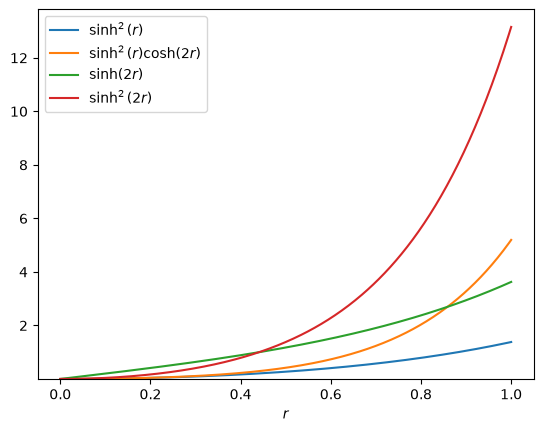

In [5]:
r = np.linspace(0, 1, 400)
terms = {
    r"$\sinh^2(r)$":           np.sinh(r)**2,
    r"$\sinh^2(r)\cosh(2r)$":  np.sinh(r)**2 * np.cosh(2*r),
    r"$\sinh(2r)$":            np.sinh(2*r),
    r"$\sinh^2(2r)$":          np.sinh(2*r)**2,
}

fig, ax = plt.subplots()
for label, y in terms.items():
    ax.plot(r, y, label=label)
ax.set(xlabel="$r$", yscale="linear", ylim=(1e-3, None))
ax.legend()
plt.show()

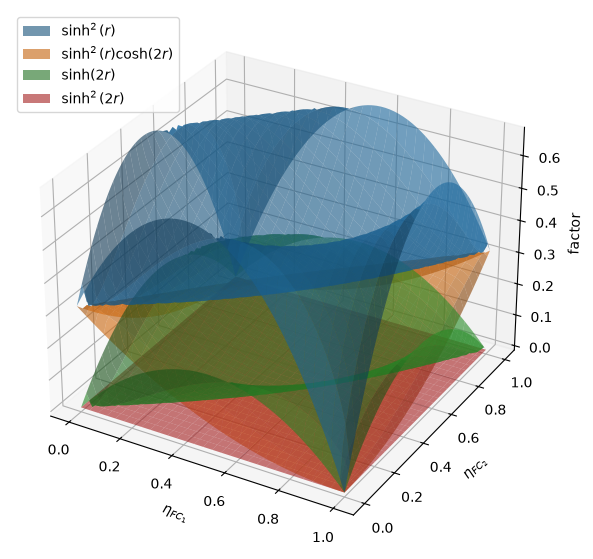

In [16]:
dth = np.pi/8

alpha, B, w0, tau = 1.0, 1.0, 2*np.pi, 1   # dth = theta - 2*phi
c, st, s = np.cos(w0*tau), np.sin(w0*tau), np.sinc(B*tau/np.pi)  # np.sinc(x) = sin(pi x)/(pi x)

e1, e2 = np.meshgrid(np.linspace(0, 1, 60), np.linspace(0, 1, 60))
z1, z2, z3, z4 = e1*e2, e1*(1-e2), (1-e1)*e2, (1-e1)*(1-e2)   # zeta_i^2
z23 = np.sqrt(z2*z3)                                            # zeta_2 zeta_3
A = z1 + z4 + 2*z23*c*s
D = z2 + z3 - 2*z23*c

surfs = {
    r"$\sinh^2(r)$":          A*(2*alpha**2*D + B/np.pi),
    r"$\sinh^2(r)\cosh(2r)$": B/np.pi * A**2,
    r"$\sinh(2r)$":           alpha**2*( np.cos(dth)*(z1*z3 + z2*z4 - 4*z2*z3*s + (z1*z2 + z3*z4)*(2*c**2-1)
                                                      + 2*z23*((z2+z3)*s - z1 - z4)*c)
                                       - 2*st*np.sin(dth)*((z3*z4 - z1*z2)*c + z23*((z3-z2)*s + z1 - z4)) ),
    r"$\sinh^2(2r)$":         -B/np.pi * z2*z3*st**2*(1 - s**2),
}

ax = plt.figure(figsize=(8, 7)).add_subplot(projection="3d")
for (label, Z), col in zip(surfs.items(), ["C0", "C1", "C2", "C3"]):
    ax.plot_surface(e1, e2, Z, color=col, alpha=0.6, label=label)
ax.set(xlabel=r"$\eta_{FC_1}$", ylabel=r"$\eta_{FC_2}$", zlabel="factor")
ax.legend()
plt.show()